# AutoEIT — Transcription Quality Analysis (WER / MER)

For every "hit" recording (item_count == 30 in `data/transcribed/v2`, see
`data/transcribed_v2_hit_recordings.txt`), `src/postprocessing/build_postprocessed_csv.py` scores
each ASR system's per-item text against both human raters and writes the result into
`data/postprocessed/{version}/{recording}/transcriptions.csv`. This notebook loads those scores,
computes average WER/MER per ASR system, and plots the comparison.

## What are WER and MER?

**WER (Word Error Rate)** is the standard ASR accuracy metric. It aligns the ASR hypothesis
against a reference transcript and counts substitutions (S), deletions (D), and insertions (I),
then divides by the number of words in the reference (N):

$$WER = \frac{S + D + I}{N}$$

A WER of 0 means a perfect match. Because insertions aren't capped by the reference length, WER
is *unbounded* — a hypothesis that's much longer than the reference (e.g. a merged/garbled
multi-item transcription) can push WER well past 100%.

**MER (Match Error Rate)** counts the same edits, but divides by the total number of aligned
words instead (S + D + C + I, where C is the count of correct words):

$$MER = \frac{S + D + I}{S + D + C + I}$$

This keeps MER strictly between 0 and 1, so it doesn't blow up on insertion-heavy errors the way
WER can. Reporting both side by side shows when a system's low WER is somewhat flattered by a
denominator quirk, versus genuinely accurate output (WER ≈ MER when insertions are rare).

Both metrics are computed after light normalization (lowercase, punctuation stripped) so
formatting-only differences (accents excluded) don't inflate the score.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## Config

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/v2")
HIT_LIST_PATH = Path("../../data/transcribed_v2_hit_recordings.txt")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["v2", "parakeet", "wav2vec2"]
RATERS = ["rater1", "rater2"]

hit_recordings = set(HIT_LIST_PATH.read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

84 hit recordings


## Load per-item WER/MER scores

Reshapes each recording's CSV into tidy rows: one row per (recording, sentence, ASR source,
rater) combination.

In [3]:
records = []

for version in VERSIONS:
    version_dir = POSTPROCESSED_ROOT / version
    for recording_dir in sorted(version_dir.iterdir()):
        recording = recording_dir.name
        if recording not in hit_recordings:
            continue
        csv_path = recording_dir / "transcriptions.csv"
        df = pd.read_csv(csv_path)
        for source in ASR_SOURCES:
            for rater in RATERS:
                wer_col, mer_col = f"{source}_wer_{rater}", f"{source}_mer_{rater}"
                if wer_col not in df.columns:
                    continue
                sub = df[["sentence_number", wer_col, mer_col]].dropna()
                for _, row in sub.iterrows():
                    records.append({
                        "version": version,
                        "recording": recording,
                        "sentence_number": row["sentence_number"],
                        "source": source,
                        "rater": rater,
                        "wer": row[wer_col],
                        "mer": row[mer_col],
                    })

scores = pd.DataFrame(records)
print(f"{len(scores)} scored items across {scores['recording'].nunique()} recordings")
scores.head()

14751 scored items across 82 recordings


,version,recording,sentence_number,source,rater,wer,mer
0,version_a,038.069_EITv-2A,1.0,v2,rater1,0.0000,0.0000
1,version_a,038.069_EITv-2A,2.0,v2,rater1,0.1429,0.1429
2,version_a,038.069_EITv-2A,3.0,v2,rater1,0.0000,0.0000
3,version_a,038.069_EITv-2A,4.0,v2,rater1,0.4000,0.4000
4,version_a,038.069_EITv-2A,5.0,v2,rater1,0.0000,0.0000


## Average WER / MER per ASR system

In [4]:
summary = (
    scores.groupby("source")[["wer", "mer"]]
    .mean()
    .reindex(ASR_SOURCES)
    .round(4)
)
summary.columns = ["mean_wer", "mean_mer"]
summary

,mean_wer,mean_mer
source,,
v2,0.2521,0.2159
parakeet,0.2713,0.2502
wav2vec2,0.3126,0.2888


Broken down by human rater used as reference:

In [5]:
by_rater = (
    scores.groupby(["source", "rater"])[["wer", "mer"]]
    .mean()
    .reindex(pd.MultiIndex.from_product([ASR_SOURCES, RATERS], names=["source", "rater"]))
    .round(4)
)
by_rater.columns = ["mean_wer", "mean_mer"]
by_rater

mean_wer  mean_mer
source   rater                     
v2       rater1    0.2588    0.2203
         rater2    0.2454    0.2115
parakeet rater1    0.2767    0.2538
         rater2    0.2658    0.2466
wav2vec2 rater1    0.3153    0.2908
         rater2    0.3099    0.2867

Broken down by version:

In [6]:
by_version = (
    scores.groupby(["source", "version"])[["wer", "mer"]]
    .mean()
    .reindex(pd.MultiIndex.from_product([ASR_SOURCES, VERSIONS], names=["source", "version"]))
    .round(4)
)
by_version.columns = ["mean_wer", "mean_mer"]
by_version

mean_wer  mean_mer
source   version                      
v2       version_a    0.2624    0.2277
         version_b    0.2412    0.2035
parakeet version_a    0.2744    0.2541
         version_b    0.2680    0.2461
wav2vec2 version_a    0.3169    0.2915
         version_b    0.3082    0.2858

## Plot — mean WER vs MER per ASR system

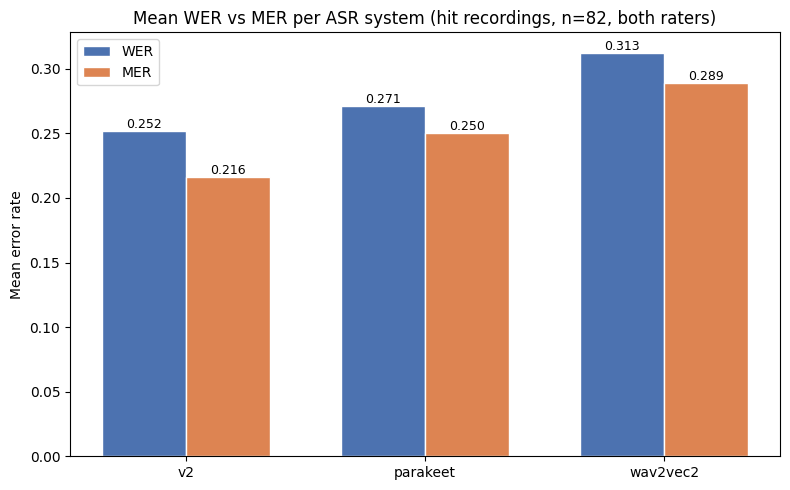

In [7]:
source_colors = {"v2": "#4C72B0", "parakeet": "#DD8452", "wav2vec2": "#55A868"}

x = np.arange(len(ASR_SOURCES))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
wer_bars = ax.bar(x - width / 2, summary["mean_wer"], width, label="WER", color="#4C72B0", edgecolor="white")
mer_bars = ax.bar(x + width / 2, summary["mean_mer"], width, label="MER", color="#DD8452", edgecolor="white")

for bars in (wer_bars, mer_bars):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

n_recordings = scores["recording"].nunique()
ax.set_xticks(x)
ax.set_xticklabels(ASR_SOURCES)
ax.set_ylabel("Mean error rate")
ax.set_title(f"Mean WER vs MER per ASR system (hit recordings, n={n_recordings}, both raters)")
ax.legend()
fig.tight_layout()
plt.savefig("../plots/transcription_quality_wer_mer.png", dpi=150)
plt.show()

## Distribution of per-item WER by ASR system

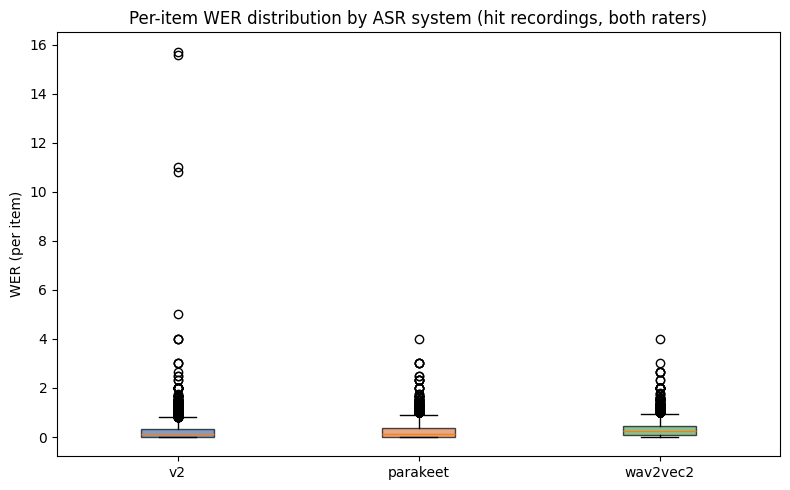

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
data = [scores.loc[scores["source"] == s, "wer"] for s in ASR_SOURCES]
bplot = ax.boxplot(data, tick_labels=ASR_SOURCES, patch_artist=True, showfliers=True)
for patch, s in zip(bplot["boxes"], ASR_SOURCES):
    patch.set_facecolor(source_colors[s])
    patch.set_alpha(0.7)

ax.set_ylabel("WER (per item)")
ax.set_title("Per-item WER distribution by ASR system (hit recordings, both raters)")
fig.tight_layout()
plt.savefig("../plots/transcription_quality_wer_distribution.png", dpi=150)
plt.show()

## Robustness check — mean vs. median

The boxplot above already hints at it: WER has a long right tail (a handful of badly garbled
items, mostly insertion-heavy, with WER well past 1.0), which pulls the **mean** up. The
**median** — the error rate for a "typical" item — is a fairer summary of everyday performance,
and the share of perfectly-transcribed items (WER == 0) shows how often each system needs no
correction at all.

In [9]:
robust_stats = (
    scores.groupby("source")["wer"]
    .describe(percentiles=[.25, .5, .75, .9])
    .round(3)
    .reindex(ASR_SOURCES)
)
robust_stats["pct_perfect"] = (
    scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(ASR_SOURCES)
)
robust_stats[["mean", "50%", "75%", "90%", "max", "pct_perfect"]]

,mean,50%,75%,90%,max,pct_perfect
source,,,,,,
v2,0.252,0.143,0.333,0.625,15.714,0.369
parakeet,0.271,0.143,0.375,0.833,4.000,0.346
wav2vec2,0.313,0.250,0.444,0.750,4.000,0.224


Reading this: for v2 and parakeet the **median** WER (~0.14) is much lower than the mean
(~0.26-0.28), and roughly a third of items are transcribed perfectly. wav2vec2's median (0.25) is
closer to its mean, so it's more consistently mediocre rather than mostly-good-with-a-bad-tail.
So the ranking from the mean-WER comparison still holds (v2 ≤ parakeet < wav2vec2), but v2 and
parakeet look considerably stronger on a "typical item" basis than the raw mean suggests.

## Word-level confidence: which ASR systems expose it?

Only some of the three systems report a per-word probability (`mean_word_prob` in the summary
JSON / postprocessed CSV):
- **v2** (faster-whisper) — reports `prob` per word directly from the model's decoder.
- **wav2vec2** — has no native word confidence, so the pipeline derives one by averaging the
  softmax max-probability of the CTC frames spanned by each word (see `_finalize_word` in
  `src/transcription/transcribe_wav2vec2.py`).
- **parakeet** (NVIDIA NeMo) — does **not** expose per-word confidence through this pipeline, so
  `mean_word_prob` is always null (see `src/transcription/transcribe_parakeet.py`).

In [10]:
prob_records = []

for version in VERSIONS:
    for recording_dir in sorted((POSTPROCESSED_ROOT / version).iterdir()):
        if recording_dir.name not in hit_recordings:
            continue
        df = pd.read_csv(recording_dir / "transcriptions.csv")
        for source in ASR_SOURCES:
            prob_col, wer_col = f"{source}_mean_word_prob", f"{source}_wer_rater1"
            if wer_col not in df.columns:
                continue
            sub = df[["sentence_number", prob_col, wer_col]].dropna(subset=[wer_col])
            for _, row in sub.iterrows():
                prob_records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "source": source,
                    "mean_word_prob": row[prob_col],
                    "wer": row[wer_col],
                })

prob_df = pd.DataFrame(prob_records)
availability = prob_df.groupby("source")["mean_word_prob"].apply(lambda x: x.notna().mean()).reindex(ASR_SOURCES)
availability.name = "fraction_with_word_prob"
availability.round(3)

source
v2          1.0
parakeet    0.0
wav2vec2    1.0
Name: fraction_with_word_prob, dtype: float64

## Can word probability flag insertion-heavy errors?

The idea: Whisper-family models occasionally hallucinate extra content (visible as WER > 1, since
insertions aren't capped by the reference length — see the WER/MER gap earlier). If those
inserted words also carry low confidence, `mean_word_prob` could be used as a signal to
detect/trim insertion-heavy segments post-hoc, without needing the human reference.

Using `wer > 1.0` as a proxy for "insertion-heavy" (an item can only exceed 1.0 if the hypothesis
has more errors than the reference has words, i.e. it's added content beyond a straight
substitution):

In [11]:
for source in ["v2", "wav2vec2"]:
    sub = prob_df[(prob_df["source"] == source) & prob_df["mean_word_prob"].notna()].copy()
    sub["insertion_heavy"] = sub["wer"] > 1.0
    corr = sub["mean_word_prob"].corr(sub["wer"])
    n_insertion_heavy = sub["insertion_heavy"].sum()
    print(f"{source}: n={len(sub)}, corr(mean_word_prob, wer) = {corr:.3f}, "
          f"n insertion-heavy = {n_insertion_heavy}")
    display(sub.groupby("insertion_heavy")["mean_word_prob"].describe().round(3))
    print()

v2: n=2460, corr(mean_word_prob, wer) = -0.414, n insertion-heavy = 62


,count,mean,std,min,25%,50%,75%,max
insertion_heavy,,,,,,,,
False,2398.0,0.893,0.116,0.211,0.853,0.934,0.975,0.999
True,62.0,0.677,0.180,0.287,0.553,0.647,0.833,0.981



wav2vec2: n=2460, corr(mean_word_prob, wer) = -0.586, n insertion-heavy = 53


,count,mean,std,min,25%,50%,75%,max
insertion_heavy,,,,,,,,
False,2407.0,0.971,0.034,0.699,0.959,0.982,0.995,1.0
True,53.0,0.916,0.059,0.732,0.884,0.925,0.964,1.0


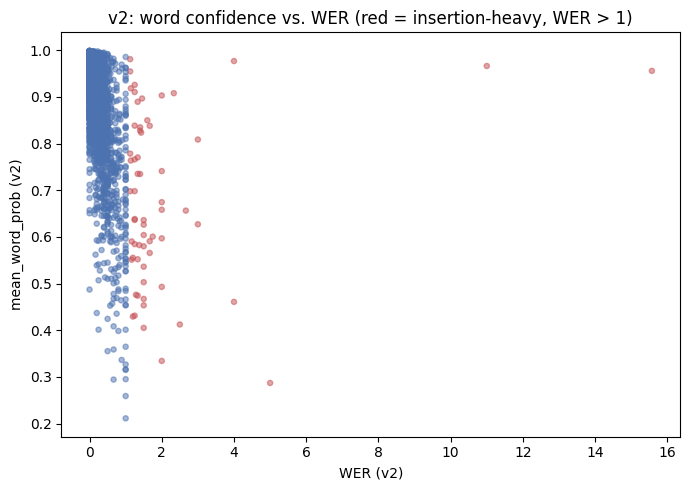

In [12]:
v2_prob = prob_df[(prob_df["source"] == "v2") & prob_df["mean_word_prob"].notna()].copy()
v2_prob["insertion_heavy"] = v2_prob["wer"] > 1.0

fig, ax = plt.subplots(figsize=(7, 5))
colors_map = v2_prob["insertion_heavy"].map({True: "#C44E52", False: "#4C72B0"})
ax.scatter(v2_prob["wer"], v2_prob["mean_word_prob"], s=14, alpha=0.5, c=colors_map)
ax.set_xlabel("WER (v2)")
ax.set_ylabel("mean_word_prob (v2)")
ax.set_title("v2: word confidence vs. WER (red = insertion-heavy, WER > 1)")
fig.tight_layout()
plt.savefig("../plots/transcription_quality_v2_prob_vs_wer.png", dpi=150)
plt.show()

**Reading this:** for v2, insertion-heavy items average a mean_word_prob of ~0.68 vs. ~0.89 for
normal items (r = -0.41) — a real, moderate signal. wav2vec2 shows a similar correlation (r =
-0.59) but a much smaller absolute gap (~0.92 vs ~0.97), because its derived softmax-based
confidence is generally overconfident/compressed near 1.0, so it's less useful as a threshold.

The separation for v2 isn't clean (the 25th percentile of insertion-heavy items still overlaps
the 75th percentile of normal ones — see the scatter plot), so a single hard confidence cutoff
would misfire on some items either way. But it's promising enough to prototype: rather than
filtering whole *items* by their mean probability, the more targeted approach is to trim
low-confidence words from the *edges* of a transcription (where hallucinated insertions tend to
show up) using the per-word `prob` values already stored in each `item_N.json` file (not just the
item-level mean used here) — e.g. drop trailing/leading words below some probability threshold
and re-measure WER/MER to see if it actually helps rather than just shortening correct output.